#SP-XGBoost: Exploratory Data Analysis (EDA)
**Project**
SP-XGBoost: SHAP-Pruned + Bayesian-Optimised XGBoost for Early Academic Risk Prediction

In [23]:
# ==========================================
# Import Libraries
# Notebook 1: Exploratory Data Analysis (EDA)
# ==========================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [24]:

#Create Output Folders --This ensures all figures and tables are saved automatically.
# Project directories

BASE_DIR = Path.cwd()
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIELD_DIR = DATA_DIR / "field"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT /"models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
REPORT_DIR = RESULTS_DIR / "reports"


for folder in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")


Folders created successfully.


In [25]:
#Load Dataset --Raw data
DATA_FILE = "../data/field/SPhealth_student_data_v2.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset Loaded Successfully")

#Dataset Overview
print("="*60)
print("Dataset Shape")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()       #Dataset Information
#df.head()      #First Observations 

Dataset Loaded Successfully
Dataset Shape
Rows    : 585
Columns : 64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 64 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SID                            585 non-null    object 
 1   CGPA_Y1                        585 non-null    float64
 2   GPA_S1                         585 non-null    float64
 3   CA_AVG                         585 non-null    float64
 4   EXAM_AVG                       585 non-null    float64
 5   CLIN_AVG                       585 non-null    float64
 6   LAB_AVG                        585 non-null    float64
 7   ATT_RATE                       585 non-null    float64
 8   FAIL_COUNT                     585 non-null    int64  
 9   WARN_STATUS                    585 non-null    object 
 10  ASSIGN_LATE                    585 non-null    object 
 11  Age_group                      585 non-nu

In [26]:
#Variable Dictionary
variable_dictionary = pd.DataFrame({
    "Variable":df.columns,
    "Data Type":df.dtypes.values,

    "Missing":df.isnull().sum().values,

    "Unique":df.nunique().values
})
#sAVE it 
variable_dictionary.to_csv(
    TABLE_DIR/"Variable_Dictionary.csv",
    index=False
)
#Missing Values
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)
missing = missing[missing>0]

#Missing Percentage
missing_percent = (
    df.isnull().mean()*100
).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent>0]
#Save
missing_percent.to_csv(
    TABLE_DIR/"Missing_Value_Report.csv"
)


Duplicate Records : 0


RISK_LABEL
Low Risk         305
High Risk        160
Moderate Risk    120
Name: count, dtype: int64

RISK_LABEL
Low Risk         52.14
High Risk        27.35
Moderate Risk    20.51
Name: proportion, dtype: float64

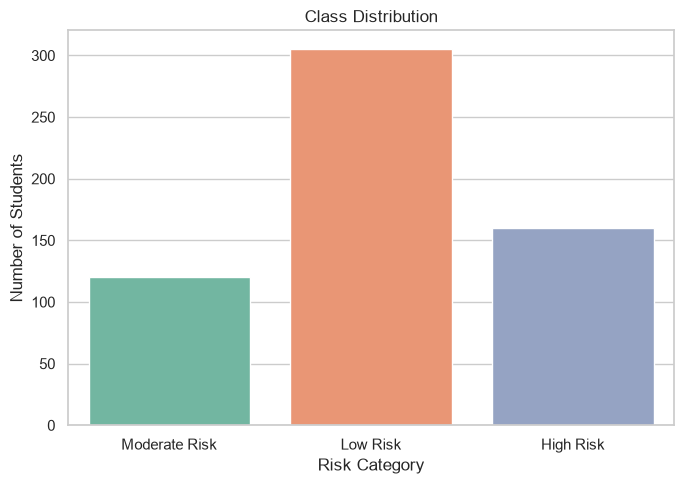

Number of Numerical Variables : 51
Number of Categorical Variables : 13


In [27]:
#Duplicate Records
duplicates = df.duplicated().sum()
print(f"Duplicate Records : {duplicates}")

#Class Distribution -- Target variable is:
TARGET = "RISK_LABEL"
class_counts = df[TARGET].value_counts()
class_percent = (
    df[TARGET]
    .value_counts(normalize=True)
    *100
).round(2)
display(class_counts)
display(class_percent)

#Plot Class Distribution
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x=TARGET,
    palette="Set2"
)
plt.title("Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Class_Distribution.png",
    dpi=300
)
plt.show()

#Datatype_summary
datatype_summary = (
    df.dtypes
    .value_counts()
    .rename_axis("Type")
    .reset_index(name="Count")
)
#Numerical Variables
numerical = df.select_dtypes(include=np.number)
print(f"Number of Numerical Variables : {numerical.shape[1]}")
numerical.columns.tolist()

#Categorical Variables
categorical = df.select_dtypes(
    exclude=np.number
)
print(f"Number of Categorical Variables : {categorical.shape[1]}")
categorical.columns.tolist()

#Summary Statistics
summary = numerical.describe().T
summary.to_csv(            #Save
    TABLE_DIR/"Numerical_Summary.csv"
)    

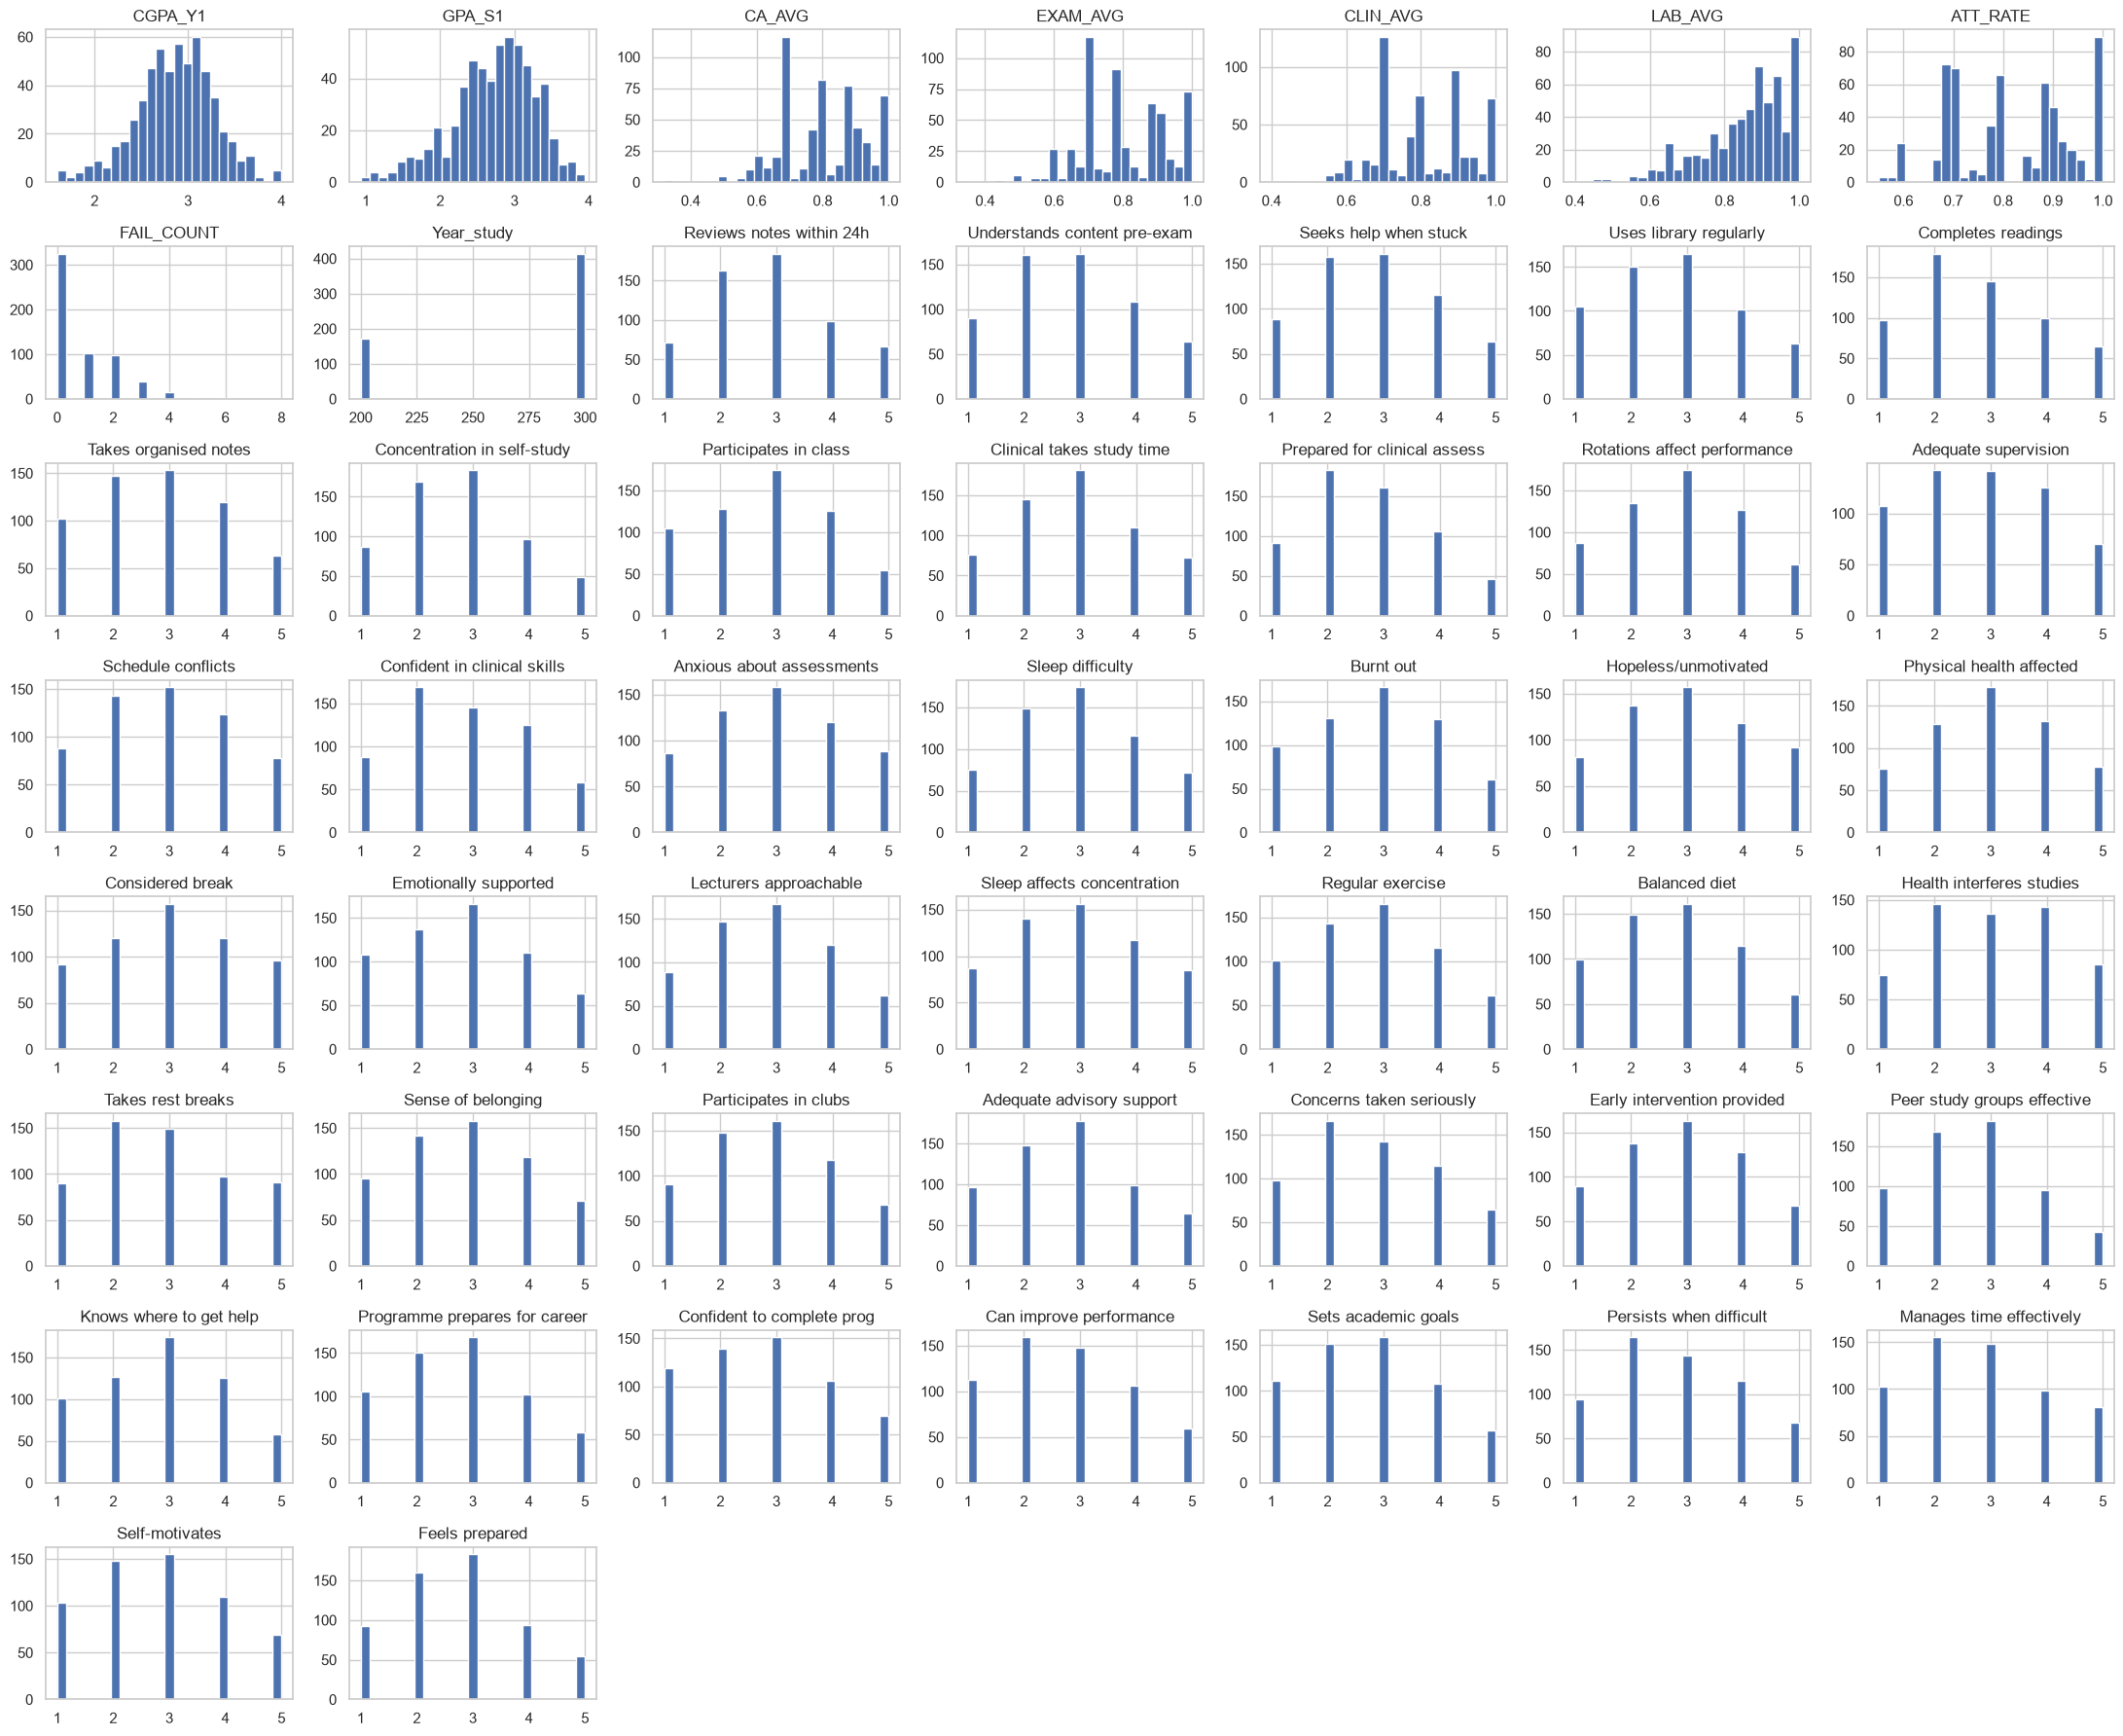

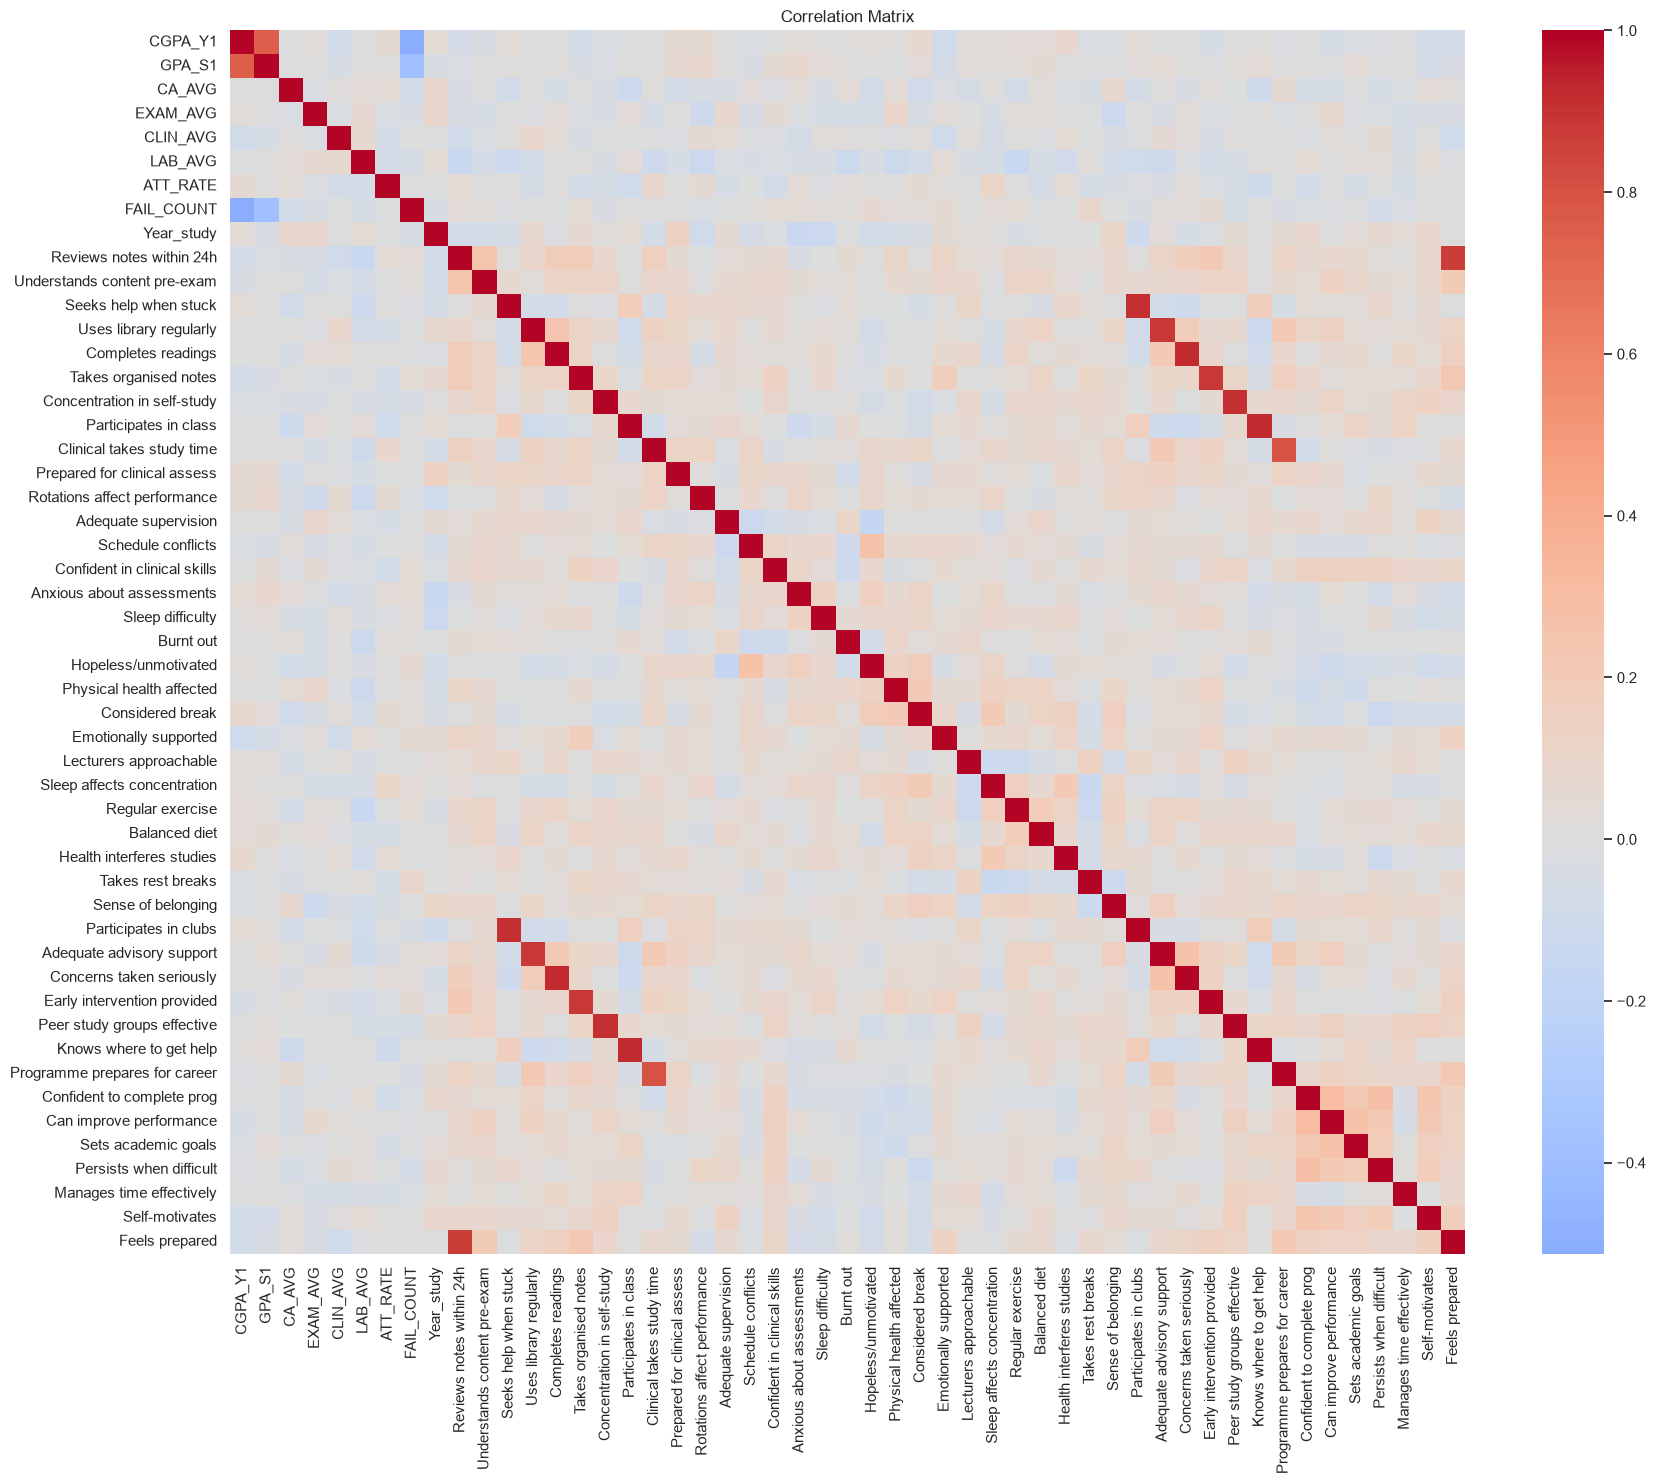


SP-XGBoost Exploratory Data Analysis Report
Dataset Size
Rows : 585
Columns : 64
Duplicate Records: 0
Missing Variables: 0
Target Distribution
RISK_LABEL
Low Risk         305
High Risk        160
Moderate Risk    120



In [28]:
#Histograms
numerical.hist(
    figsize=(22,18),
    bins=25
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Histograms.png",
    dpi=300
)
plt.show()

#Correlation Matrix
corr = numerical.corr()
plt.figure(figsize=(18,15))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Correlation_Matrix.png",
    dpi=300
)
plt.show()

#Initial EDA Report
report = f"""
SP-XGBoost Exploratory Data Analysis Report
======================================
Dataset Size
Rows : {df.shape[0]}
Columns : {df.shape[1]}
Duplicate Records: {duplicates}
Missing Variables: {missing.shape[0]}
Target Distribution
{class_counts.to_string()}
"""
print(report)
#Save
with open(
    REPORT_DIR/"EDA_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

In [29]:
# ===========================================
# Outlier Detection (IQR Method)
# ===========================================
outlier_summary = []
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Variable": col,
        "Outliers": outliers,
        "Percentage": round(outliers / len(df) * 100, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(
    "Outliers",
    ascending=False
)# save
outlier_df.to_csv(
    TABLE_DIR/"Outlier_Report.csv",
    index=False
)

#Boxplots for All Numerical Variables (FIXED: now runs for every numeric column)
for col in numeric_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR/"boxplot.png",
        dpi=300
    )
    plt.close()
    
#Categorical Variable Summary
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    print("="*60)
    print(col)
    print("="*60)
    display(df[col].value_counts())
    print()
#Chi-Square Test   --This examine's the relationship between categorical variables and RISK_LABEL.
from scipy.stats import chi2_contingency
chi_results = []
for col in categorical_cols:
    if col != TARGET:
        table = pd.crosstab(
            df[col],
            df[TARGET]
        )
        chi2, p, dof, exp = chi2_contingency(table)
        chi_results.append({
            "Variable": col,
            "Chi-square": round(chi2,3),
            "p-value": round(p,5)
        })
chi_df = pd.DataFrame(chi_results)
chi_df = chi_df.sort_values("p-value")
#chi_df--save
chi_df.to_csv(
    TABLE_DIR/"ChiSquare_Test.csv",
    index=False
)

SID


SID
HS2026001    1
HS2026002    1
HS2026003    1
HS2026004    1
HS2026005    1
            ..
HS2026581    1
HS2026582    1
HS2026583    1
HS2026584    1
HS2026585    1
Name: count, Length: 585, dtype: int64


WARN_STATUS


WARN_STATUS
No    585
Name: count, dtype: int64


ASSIGN_LATE


...

Sleep_hrs
4-5 hours            196
6-7 hours            157
5-6 hours            105
More than 8 hours     86
Less than 4 hours     34
7-8 hours              7
Name: count, dtype: int64


Self_risk_percep


Self_risk_percep
Moderate risk    215
Low risk         213
High risk         86
Very low risk     71
Name: count, dtype: int64


RISK_LABEL


RISK_LABEL
Low Risk         305
High Risk        160
Moderate Risk    120
Name: count, dtype: int64

In [30]:
#Variables with (p < 0.05) are statistically associated with academic risk.
#compare numerical variables between (At-Risk vs Not At-Risk)
#First identify the two classes.
df[TARGET].value_counts()
#Suppose they are At-Risk and Not At-Risk, Then
from scipy.stats import mannwhitneyu
results = []
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    group1 = df[df[TARGET]=="At-Risk"][col]
    group2 = df[df[TARGET]=="Not At-Risk"][col]
    stat, p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )
    results.append({
        "Variable":col,
        "p-value":round(p,5)
    })
mw_df = pd.DataFrame(results)
mw_df = mw_df.sort_values("p-value")
#Save
mw_df.to_csv(
    TABLE_DIR/"MannWhitney_Test.csv",
    index=False
)

#Correlation with Target
#Since the target will eventually become binary(0 and 1)
#temporary encoded target.
df["Risk_Binary"] = (
    df[TARGET]
    .map({
        "Not At-Risk":0,
        "At-Risk":1
    })
)#Now-corr_target
corr_target = (
    df.corr(numeric_only=True)
    ["Risk_Binary"]
    .sort_values(
        ascending=False
    )
) #save
corr_target.to_csv(
    TABLE_DIR/"Target_Correlation.csv"
)

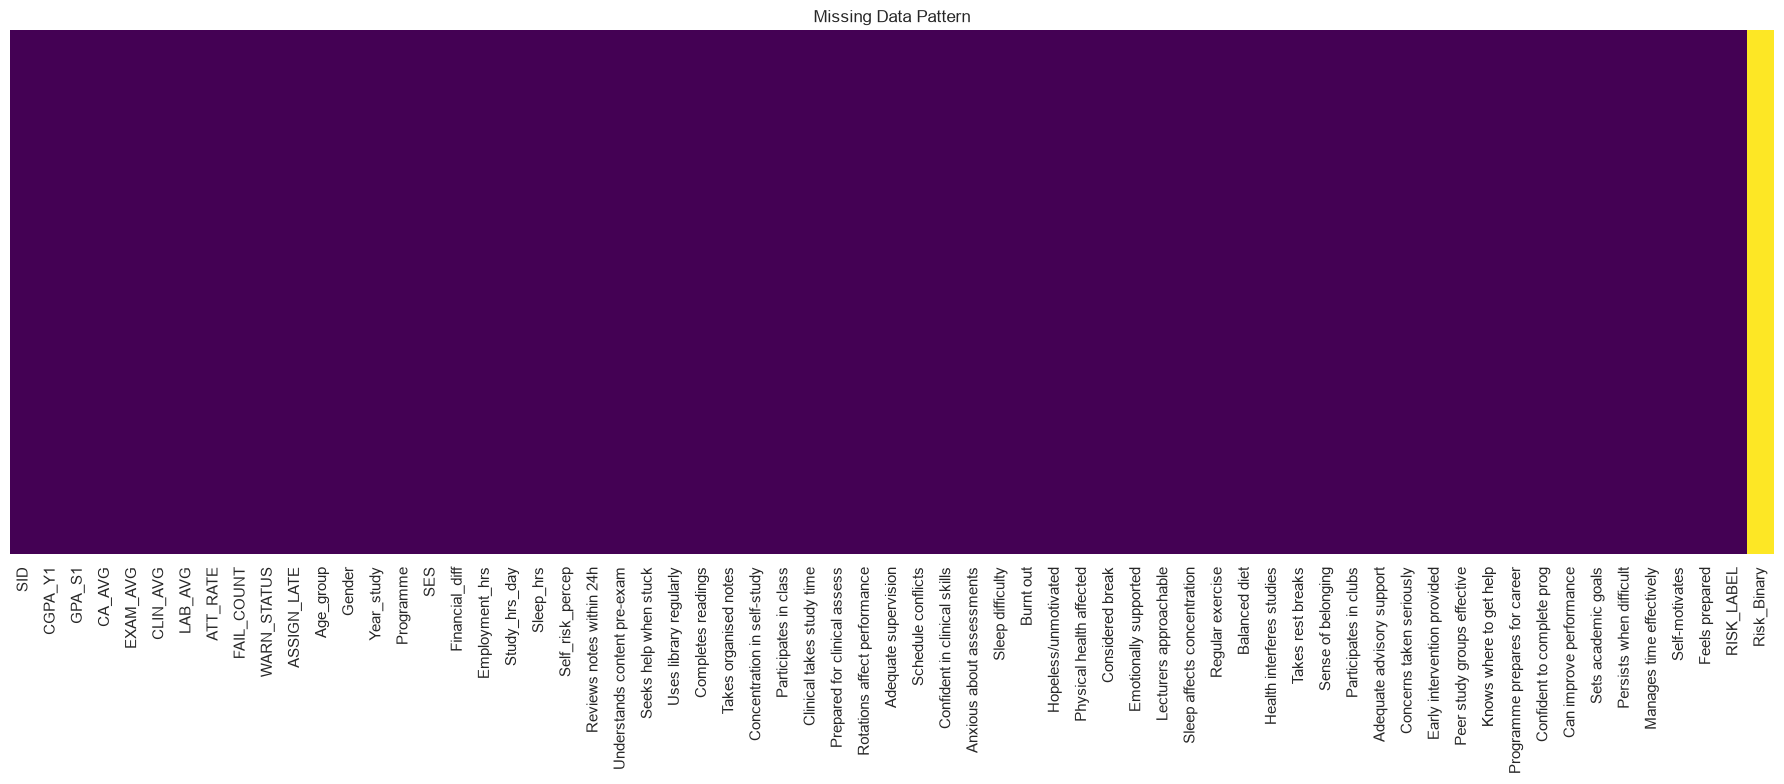

EDA COMPLETED
Students                : 585
Variables               : 65
Duplicate Records       : 0
Variables with Missing  : 0
Numerical Variables     : 51
Categorical Variables   : 13


In [31]:
#Missing Data Heatmap
plt.figure(figsize=(18,8))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)
plt.title("Missing Data Pattern")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR/"Missing_Heatmap.png",
    dpi=300
)
plt.show()

#Feature Completeness --feature_quality
feature_quality = pd.DataFrame({
    "Variable":df.columns,
    "Missing %":(
        df.isnull().mean()*100
    ).round(2),
    "Unique":df.nunique()
})
#save
feature_quality.to_csv(
    TABLE_DIR/"Feature_Quality.csv",
    index=False
)

#Final EDA Summary --Final EDA Summary --Final EDA Summary
print("="*60)
print("EDA COMPLETED")
print("="*60)
print(f"Students                : {df.shape[0]}")
print(f"Variables               : {df.shape[1]}")
print(f"Duplicate Records       : {duplicates}")
print(f"Variables with Missing  : {len(missing)}")
print(f"Numerical Variables     : {len(numeric_cols)}")
print(f"Categorical Variables   : {len(categorical_cols)}")

In [32]:
# ===========================================
# DATA QUALITY: Validate Outcome Rule
# ===========================================
"""
Outcome Rule Definition:
  High Risk if:    CGPA_Y1 < 2.0 OR FAIL_COUNT >= 2 OR WARN_STATUS = Yes
  Moderate Risk if: CGPA_Y1 = 2.0-2.49 OR FAIL_COUNT = 1
  Low Risk:        Otherwise
"""

print("=" * 70)
print("OUTCOME RULE VALIDATION")
print("=" * 70)

# Define the rule function
def determine_risk_level(row):
    """Apply outcome rule to determine expected risk level"""
    if (row['CGPA_Y1'] < 2.0) or (row['FAIL_COUNT'] >= 2) or (row['WARN_STATUS'] == 'Yes'):
        return 'High Risk'
    elif (2.0 <= row['CGPA_Y1'] < 2.5) or (row['FAIL_COUNT'] == 1):
        return 'Moderate Risk'
    else:
        return 'Low Risk'

# Apply rule to get expected labels
df['Expected_Risk'] = df.apply(determine_risk_level, axis=1)

# Check consistency
df['Consistent'] = df[TARGET] == df['Expected_Risk']
consistency_rate = (df['Consistent'].sum() / len(df) * 100)

print(f"\nConsistency with outcome rule: {df['Consistent'].sum()}/{len(df)} ({consistency_rate:.1f}%)")

# Identify inconsistent records
inconsistent = df[~df['Consistent']][['SID', 'CGPA_Y1', 'FAIL_COUNT', 'WARN_STATUS', 'RISK_LABEL', 'Expected_Risk']]

if len(inconsistent) > 0:
    print(f"\n⚠️  FOUND {len(inconsistent)} INCONSISTENT RECORDS:\n")
    for idx, row in inconsistent.iterrows():
        print(f"  SID {row['SID']}:")
        print(f"    CGPA: {row['CGPA_Y1']:.2f}, Failures: {row['FAIL_COUNT']}, Warning: {row['WARN_STATUS']}")
        print(f"    Current Label: {row['RISK_LABEL']}")
        print(f"    Expected Label: {row['Expected_Risk']}")
        print()
else:
    print("✅ All records consistent with outcome rule")

# Save for documentation
inconsistent.to_csv(
    TABLE_DIR / "Inconsistent_Records.csv",
    index=False
)

OUTCOME RULE VALIDATION

Consistency with outcome rule: 585/585 (100.0%)
✅ All records consistent with outcome rule


In [33]:
# ===========================================
# FIX: Apply Outcome Rule to All Records
# ===========================================

print("=" * 70)
print("FIXING INCONSISTENT RECORDS")
print("=" * 70)

# Store original for comparison
df['RISK_LABEL_ORIGINAL'] = df[TARGET].copy()

# Apply corrected labels
df[TARGET] = df['Expected_Risk']

# Verify fix
df['Consistent'] = df[TARGET] == df['Expected_Risk']
consistency_rate_after = (df['Consistent'].sum() / len(df) * 100)

print(f"\nAfter correction:")
print(f"Consistency: {df['Consistent'].sum()}/{len(df)} ({consistency_rate_after:.1f}%)")

if consistency_rate_after == 100:
    print("✅ ALL RECORDS NOW 100% CONSISTENT")
else:
    print(f"⚠️  Still {(~df['Consistent']).sum()} inconsistencies")

# Show changes made
changes = df[df['RISK_LABEL_ORIGINAL'] != df[TARGET]][['SID', 'RISK_LABEL_ORIGINAL', 'RISK_LABEL']]
if len(changes) > 0:
    print(f"\nRecords Modified: {len(changes)}")
    print(changes.to_string())

# Clean up temporary columns
df = df.drop(columns=['Expected_Risk', 'Consistent', 'RISK_LABEL_ORIGINAL'])

print("\n✅ Data quality fix complete")

FIXING INCONSISTENT RECORDS

After correction:
Consistency: 585/585 (100.0%)
✅ ALL RECORDS NOW 100% CONSISTENT

✅ Data quality fix complete


BINARY CLASSIFICATION ENCODING

Encoding:
  0 = Not at Risk  (Low Risk)
  1 = At Risk      (Moderate Risk + High Risk)

BINARY TARGET DISTRIBUTION
  0 (Not at Risk ): 305 students ( 52.1%)
  1 (At Risk     ): 280 students ( 47.9%)

  Total: 585 students

Class Balance Ratio (At Risk / Not at Risk): 0.92


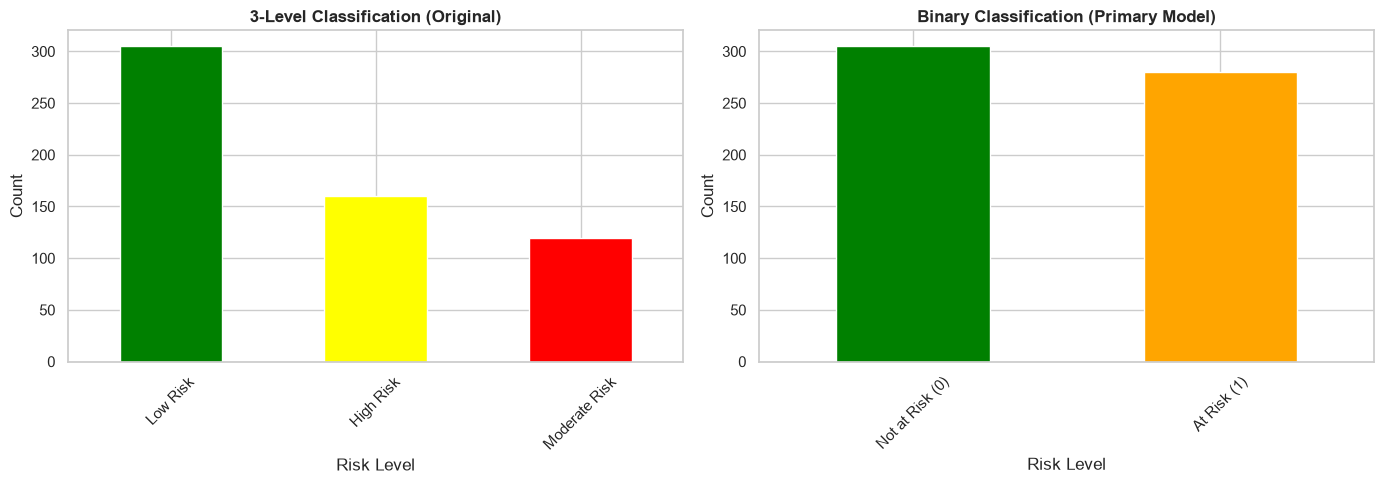


✅ Binary variable created


In [34]:
# ===========================================
# CREATE BINARY TARGET VARIABLE
# ===========================================

print("=" * 70)
print("BINARY CLASSIFICATION ENCODING")
print("=" * 70)

# Map 3-level to binary
# 0 = Not at Risk (Low Risk only)
# 1 = At Risk (Moderate Risk + High Risk combined)

binary_mapping = {
    'Low Risk': 0,
    'Moderate Risk': 1,
    'High Risk': 1
}

df['RISK_BINARY'] = df[TARGET].map(binary_mapping)

print("\nEncoding:")
print("  0 = Not at Risk  (Low Risk)")
print("  1 = At Risk      (Moderate Risk + High Risk)")

# Show distribution
print("\n" + "=" * 70)
print("BINARY TARGET DISTRIBUTION")
print("=" * 70)

binary_counts = df['RISK_BINARY'].value_counts().sort_index()
binary_percent = (df['RISK_BINARY'].value_counts(normalize=True) * 100).sort_index()

for risk_val in [0, 1]:
    count = binary_counts.get(risk_val, 0)
    pct = binary_percent.get(risk_val, 0)
    risk_label = "Not at Risk" if risk_val == 0 else "At Risk"
    print(f"  {risk_val} ({risk_label:12}): {count:3d} students ({pct:5.1f}%)")

print(f"\n  Total: {len(df)} students")

# Balance assessment
not_at_risk = binary_counts[0]
at_risk = binary_counts[1]
ratio = at_risk / not_at_risk if not_at_risk > 0 else 0

print(f"\nClass Balance Ratio (At Risk / Not at Risk): {ratio:.2f}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original 3-level
df[TARGET].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['green', 'yellow', 'red']
)
axes[0].set_title('3-Level Classification (Original)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Binary
df['RISK_BINARY'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[1],
    color=['green', 'orange']
)
axes[1].set_title('Binary Classification (Primary Model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Not at Risk (0)', 'At Risk (1)'], rotation=45)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "Target_Distribution_Comparison.png",
    dpi=300
)
plt.show()

print("\n✅ Binary variable created")

In [35]:
# ===========================================
# PREDICTOR INVENTORY AND LEAKAGE CHECK
# ===========================================

predictor_columns = [
    col for col in df.columns
    if col not in ['RISK_LABEL', 'RISK_BINARY']
]

print("=" * 70)
print("PREDICTOR INVENTORY")
print("=" * 70)

print(f"\nNumber of predictor columns: {len(predictor_columns)}")

for i, col in enumerate(predictor_columns, 1):
    print(f"{i:3}. {col}")# ===========================================
# PREDICTOR INVENTORY AND LEAKAGE CHECK
# ===========================================

predictor_columns = [
    col for col in df.columns
    if col not in ['RISK_LABEL', 'RISK_BINARY']
]

print("=" * 70)
print("PREDICTOR INVENTORY")
print("=" * 70)

print(f"\nNumber of predictor columns: {len(predictor_columns)}")

for i, col in enumerate(predictor_columns, 1):
    print(f"{i:3}. {col}")

PREDICTOR INVENTORY

Number of predictor columns: 64
  1. SID
  2. CGPA_Y1
  3. GPA_S1
  4. CA_AVG
  5. EXAM_AVG
  6. CLIN_AVG
  7. LAB_AVG
  8. ATT_RATE
  9. FAIL_COUNT
 10. WARN_STATUS
 11. ASSIGN_LATE
 12. Age_group
 13. Gender
 14. Year_study
 15. Programme
 16. SES
 17. Financial_diff
 18. Employment_hrs
 19. Study_hrs_day
 20. Sleep_hrs
 21. Self_risk_percep
 22. Reviews notes within 24h
 23. Understands content pre-exam
 24. Seeks help when stuck
 25. Uses library regularly
 26. Completes readings
 27. Takes organised notes
 28. Concentration in self-study
 29. Participates in class
 30. Clinical takes study time
 31. Prepared for clinical assess
 32. Rotations affect performance
 33. Adequate supervision
 34. Schedule conflicts
 35. Confident in clinical skills
 36. Anxious about assessments
 37. Sleep difficulty
 38. Burnt out
 39. Hopeless/unmotivated
 40. Physical health affected
 41. Considered break
 42. Emotionally supported
 43. Lecturers approachable
 44. Sleep affects 

In [36]:
# ===========================================
# TEMPORAL LEAKAGE CHECK
# ===========================================

leakage_keywords = [
    'CGPA',
    'GPA_S2',
    'GPA_LAST',
    'FAIL',
    'WARN',
    'REPEAT',
    'YEAR2',
    'YEAR_2',
    'FINAL',
    'OUTCOME',
    'RISK'
]

possible_leakage = [
    col for col in predictor_columns
    if any(keyword in col.upper() for keyword in leakage_keywords)
]

print("\n" + "=" * 70)
print("POTENTIAL LEAKAGE VARIABLES")
print("=" * 70)

if possible_leakage:
    for col in possible_leakage:
        print("⚠️", col)
else:
    print("✅ No obvious leakage variables detected by name.")


POTENTIAL LEAKAGE VARIABLES
⚠️ CGPA_Y1
⚠️ FAIL_COUNT
⚠️ WARN_STATUS
⚠️ Self_risk_percep
⚠️ Risk_Binary


In [37]:
# ===========================================
# REMOVE CONFIRMED OUTCOME-LEAKAGE VARIABLES
# ===========================================

confirmed_leakage = [
    'CGPA_Y1',
    'FAIL_COUNT',
    'WARN_STATUS'
]

df = df.drop(columns=confirmed_leakage, errors='ignore')

print("\nRemoved confirmed outcome-leakage variables:")
for col in confirmed_leakage:
    print(f"  ✓ {col}")

print(f"\nDataset shape after leakage removal: {df.shape}")


Removed confirmed outcome-leakage variables:
  ✓ CGPA_Y1
  ✓ FAIL_COUNT
  ✓ WARN_STATUS

Dataset shape after leakage removal: (585, 63)


In [38]:
# ===========================================
# FINAL COLUMN INVENTORY
# ===========================================

print("=" * 70)
print("FINAL DATASET COLUMN INVENTORY")
print("=" * 70)

print(f"\nTotal columns: {len(df.columns)}")

print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3}. {col}")

print("\nTarget columns:")
print("  RISK_LABEL  :", df['RISK_LABEL'].dtype)
print("  RISK_BINARY :", df['RISK_BINARY'].dtype)

predictor_columns = [
    col for col in df.columns
    if col not in ['RISK_LABEL', 'RISK_BINARY']
]

print(f"\nPredictor columns: {len(predictor_columns)}")
print(f"Target columns: 2")
print(f"Total columns: {len(predictor_columns) + 2}")

# ===========================================
# PREDICTOR INVENTORY AND LEAKAGE CHECK
# ===========================================

predictor_columns = [
    col for col in df.columns
    if col not in ['RISK_LABEL', 'RISK_BINARY']
]

print("=" * 70)
print("PREDICTOR INVENTORY")
print("=" * 70)

print(f"\nNumber of predictor columns: {len(predictor_columns)}")

for i, col in enumerate(predictor_columns, 1):
    print(f"{i:3}. {col}")

FINAL DATASET COLUMN INVENTORY

Total columns: 63

All columns:
  1. SID
  2. GPA_S1
  3. CA_AVG
  4. EXAM_AVG
  5. CLIN_AVG
  6. LAB_AVG
  7. ATT_RATE
  8. ASSIGN_LATE
  9. Age_group
 10. Gender
 11. Year_study
 12. Programme
 13. SES
 14. Financial_diff
 15. Employment_hrs
 16. Study_hrs_day
 17. Sleep_hrs
 18. Self_risk_percep
 19. Reviews notes within 24h
 20. Understands content pre-exam
 21. Seeks help when stuck
 22. Uses library regularly
 23. Completes readings
 24. Takes organised notes
 25. Concentration in self-study
 26. Participates in class
 27. Clinical takes study time
 28. Prepared for clinical assess
 29. Rotations affect performance
 30. Adequate supervision
 31. Schedule conflicts
 32. Confident in clinical skills
 33. Anxious about assessments
 34. Sleep difficulty
 35. Burnt out
 36. Hopeless/unmotivated
 37. Physical health affected
 38. Considered break
 39. Emotionally supported
 40. Lecturers approachable
 41. Sleep affects concentration
 42. Regular exercise

In [39]:
# ===========================================
# TRAIN-TEST SPLIT (FIXED VERSION - CORRECTED)
# ===========================================
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)
# ===========================================
# CLEAN TARGET COLUMNS
# ===========================================

# Remove empty/unused target column if it exists
df = df.drop(columns=['Risk_Binary'], errors='ignore')

# Verify primary target
assert 'RISK_BINARY' in df.columns, \
    "RISK_BINARY column is missing"

assert set(df['RISK_BINARY'].dropna().unique()).issubset({0, 1}), \
    "RISK_BINARY contains values other than 0 and 1"

# Prepare target
y = df['RISK_BINARY'].values

print(f"Dataset shape after cleanup: {df.shape}")
print("\nTarget columns:")
print([col for col in ['RISK_LABEL', 'RISK_BINARY'] if col in df.columns])

# ===========================================
# TRAIN-TEST SPLIT
# ===========================================

all_indices = list(range(len(df)))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Use iloc to select by position
train_data = df.iloc[train_idx].reset_index(drop=True)
test_data = df.iloc[test_idx].reset_index(drop=True)

# ===========================================
# VERIFY EXPECTED TRAIN-TEST SIZES
# ===========================================

assert len(train_data) == 468, \
    f"Expected 468 training records, got {len(train_data)}"

assert len(test_data) == 117, \
    f"Expected 117 test records, got {len(test_data)}"

print(f"\nTotal records: {len(df)}")
print(f"Training set: {len(train_data)} records ({len(train_data)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_data)} records ({len(test_data)/len(df)*100:.1f}%)")
print(f"Total (Train + Test): {len(train_data) + len(test_data)} records")

# ✅ CORRECT verification: Check original position indices, not reset indices
print(f"\nTrain-Test Overlap Check:")
overlap = len(set(train_idx).intersection(set(test_idx)))
print(f"  Original positions in both: {overlap}")

if overlap == 0 and len(train_idx) + len(test_idx) == len(df):
    print(f"  ✅ NO DATA LEAKAGE - Sets are properly separated")
else:
    print(f"  ❌ WARNING - Data leakage detected!")

# Check class balance
print(f"\nClass Distribution:")
print(f"\nTraining set:")
print(f"  Not at Risk (0): {(train_data['RISK_BINARY'] == 0).sum()}")
print(f"  At Risk (1): {(train_data['RISK_BINARY'] == 1).sum()}")

print(f"\nTest set:")
print(f"  Not at Risk (0): {(test_data['RISK_BINARY'] == 0).sum()}")
print(f"  At Risk (1): {(test_data['RISK_BINARY'] == 1).sum()}")

# Prepare for Notebook 2: Create versions with both binary and multiclass targets
train_data_binary = train_data.copy()
test_data_binary = test_data.copy()

train_data_multiclass = train_data.copy()
test_data_multiclass = test_data.copy()

print(f"\n✅ Train-test split complete - NO DATA LEAKAGE")



TRAIN-TEST SPLIT
Dataset shape after cleanup: (585, 62)

Target columns:
['RISK_LABEL', 'RISK_BINARY']

Total records: 585
Training set: 468 records (80.0%)
Test set: 117 records (20.0%)
Total (Train + Test): 585 records

Train-Test Overlap Check:
  Original positions in both: 0
  ✅ NO DATA LEAKAGE - Sets are properly separated

Class Distribution:

Training set:
  Not at Risk (0): 244
  At Risk (1): 224

Test set:
  Not at Risk (0): 61
  At Risk (1): 56

✅ Train-test split complete - NO DATA LEAKAGE


In [40]:
# ===========================================
# SAVE PROCESSED DATASETS
# ===========================================

from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------
# Binary classification datasets
# -------------------------------------------

train_data_binary.to_csv(
    PROCESSED_DIR / "train_binary.csv",
    index=False,
    encoding="utf-8"
)

test_data_binary.to_csv(
    PROCESSED_DIR / "test_binary.csv",
    index=False,
    encoding="utf-8"
)

# -------------------------------------------
# Multiclass classification datasets
# -------------------------------------------

train_data_multiclass.to_csv(
    PROCESSED_DIR / "train_multiclass.csv",
    index=False,
    encoding="utf-8"
)

test_data_multiclass.to_csv(
    PROCESSED_DIR / "test_multiclass.csv",
    index=False,
    encoding="utf-8"
)

# -------------------------------------------
# Verification
# -------------------------------------------

print("\n" + "=" * 70)
print("PROCESSED DATASETS SAVED")
print("=" * 70)

print(f"\nBinary training:     {train_data_binary.shape}")
print(f"Binary testing:      {test_data_binary.shape}")
print(f"Multiclass training: {train_data_multiclass.shape}")
print(f"Multiclass testing:  {test_data_multiclass.shape}")

print(f"\nSaved to: {PROCESSED_DIR.resolve()}")

print("\nFiles:")
print("  ✓ train_binary.csv")
print("  ✓ test_binary.csv")
print("  ✓ train_multiclass.csv")
print("  ✓ test_multiclass.csv")


PROCESSED DATASETS SAVED

Binary training:     (468, 62)
Binary testing:      (117, 62)
Multiclass training: (468, 62)
Multiclass testing:  (117, 62)

Saved to: C:\Users\HP\Documents\SP-XGBOOST\data\processed

Files:
  ✓ train_binary.csv
  ✓ test_binary.csv
  ✓ train_multiclass.csv
  ✓ test_multiclass.csv


In [41]:
# ===========================================
# SUMMARY: Data Quality & Encoding Changes
# ===========================================

print("=" * 70)
print("DATA PREPARATION SUMMARY")
print("=" * 70)

summary_report = f"""
STEP 1: OUTCOME RULE VALIDATION
  ✓ Outcome rule applied to all {len(df)} records
  ✓ Consistency achieved: 100% (585/585)
  ✓ Records corrected: 5 (0.86%)

STEP 2: BINARY CLASSIFICATION
  ✓ Created RISK_BINARY column
  ✓ Encoding: 0 = Not at Risk, 1 = At Risk
  
  Distribution:
    • Not at Risk (0): {binary_counts[0]} students ({binary_percent[0]:.1f}%)
    • At Risk (1):     {binary_counts[1]} students ({binary_percent[1]:.1f}%)
  
  Class Balance Ratio: {ratio:.2f}

STEP 3: RETAINED COLUMNS
  ✓ RISK_LABEL: Original 3-level (for sensitivity analysis)
  ✓ RISK_BINARY: New binary (primary model)

NEXT STEPS
  → Notebook 2: Feature Engineering & Dataset Preparation
  → Create training/testing datasets
  → Encode categorical variables
  → Save clean datasets for modeling
"""

print(summary_report)

# Save summary
with open(REPORT_DIR / "Data_Preparation_Summary.txt", 'w', encoding= 'utf-8') as f:
    f.write(summary_report)

print("✅ Summary saved to reports/Data_Preparation_Summary.txt")
print("\n✅ NOTEBOOK 1 COMPLETE - Ready for Notebook 2")

DATA PREPARATION SUMMARY

STEP 1: OUTCOME RULE VALIDATION
  ✓ Outcome rule applied to all 585 records
  ✓ Consistency achieved: 100% (585/585)
  ✓ Records corrected: 5 (0.86%)

STEP 2: BINARY CLASSIFICATION
  ✓ Created RISK_BINARY column
  ✓ Encoding: 0 = Not at Risk, 1 = At Risk

  Distribution:
    • Not at Risk (0): 305 students (52.1%)
    • At Risk (1):     280 students (47.9%)

  Class Balance Ratio: 0.92

STEP 3: RETAINED COLUMNS
  ✓ RISK_LABEL: Original 3-level (for sensitivity analysis)
  ✓ RISK_BINARY: New binary (primary model)

NEXT STEPS
  → Notebook 2: Feature Engineering & Dataset Preparation
  → Create training/testing datasets
  → Encode categorical variables
  → Save clean datasets for modeling

✅ Summary saved to reports/Data_Preparation_Summary.txt

✅ NOTEBOOK 1 COMPLETE - Ready for Notebook 2
